# Manufacturing Operations Intelligence Platform
## Comprehensive Data Profiling & Quality Assessment (SECOM)

**Project Stage:** Step 1 & 2 — Data Ingestion, Profiling, & Architecture  
**Author:** Operations Data Engineering Team  
**Dataset:** UCI Machine Learning Repository — Semiconductor Manufacturing Process (SECOM, ID: 179)  
**Target Variable:** Production Quality (`-1` = Pass / Conforming, `1` = Fail / Defective)


---
## 1. Business Problem

Semiconductor fabrication plants (fabs) operate under extreme process complexity, where silicon wafers undergo hundreds of chemical, physical, and lithographic stages. 

* **The Challenge:** Small environmental shifts, chamber degradation, or gas imbalances lead to defective wafers.
* **The Cost of Failure:** Yield excursions cost hundreds of thousands of pounds in scrapped inventory and delayed delivery schedules.
* **The Core Objective:** Design an integrated operations intelligence platform that transforms raw manufacturing telemetry (590 sensor variables) into automated data quality checks, early failure risk predictions, and executive operational decision support.

```text
[ Raw Telemetry ] ──► [ Data Quality Gates ] ──► [ PostgreSQL Warehouse ]
                                                          │
          ┌───────────────────────────────────────────────┴───────────────────────────────┐
          ▼                                                                               ▼
[ ML Yield-Risk Prediction ]                                                    [ Operations Cockpit ]
 (Cost-Sensitive Classifier + SHAP)                                              (Yield KPIs & Shift Analytics)
```


---
## 2. Dataset Overview

The dataset is acquired reproducibly via `ucimlrepo` directly from the UCI Machine Learning Repository:
* **Entities:** 1,567 manufacturing production runs (wafers/lots)
* **Temporal Window:** July 19, 2008 to October 17, 2008 (approx. 90 operational days)
* **Sensor Metrics:** 590 continuous process variables (`Attribute 1` to `Attribute 590`)
* **Target Label:** `class` where `-1` represents conforming units and `1` represents non-conforming (failed) units


---
## 3. Data Architecture

The platform implements a **3-tier data architecture** designed for production data engineering:

1. **`staging` (Raw Layer):** Immutable landing table storing `production_id`, `event_timestamp`, `quality_label`, and raw measurements as `JSONB`.
2. **`core` (Normalized Layer):** Dimensional tables separating entities into `dim_production_entity`, `dim_sensor`, and `fact_quality_outcome`.
3. **`analytics` (Serving Layer):** Aggregated daily yield views, shift performance comparisons, and feature matrices for ML.


---
## 4. Dataset Structure & Inspection

Let's load the preserved raw CSV files and verify basic dimensional integrity.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Set plot styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

RAW_DIR = Path("../data/raw")
QUALITY_DIR = Path("../data/quality")

# Load raw datasets
features = pd.read_csv(RAW_DIR / "secom_features_raw.csv")
labels = pd.read_csv(RAW_DIR / "secom_labels_raw.csv")

print(f"Features Matrix: {features.shape[0]:,} rows x {features.shape[1]:,} columns")
print(f"Labels Vector:   {labels.shape[0]:,} rows x {labels.shape[1]:,} columns")

# Verify timestamp column
timestamps = pd.to_datetime(features["timestamp"], format="mixed", dayfirst=True)
print(f"Earliest Production Run: {timestamps.min()}")
print(f"Latest Production Run:   {timestamps.max()}")
print(f"Operating Span:          {(timestamps.max() - timestamps.min()).days} days")


Features Matrix: 1,567 rows x 591 columns
Labels Vector:   1,567 rows x 1 columns
Earliest Production Run: 2008-07-19 11:55:00
Latest Production Run:   2008-10-17 06:07:00
Operating Span:          89 days


---
## 5. Data Quality Assessment

Automated profiling ran via `src/quality/generate_quality_report.py`. Let's inspect the quality health scorecard.


In [2]:
with open(QUALITY_DIR / "data_quality_summary.json", "r") as f:
    summary = json.load(f)

for k, v in summary.items():
    print(f"{k:30s}: {v}")


dataset                       : SECOM
rows                          : 1567
features                      : 591
duplicate_rows                : 0
missing_value_rate_pct        : 4.54
columns_gt_50_pct_missing     : 28
constant_columns              : 116
pass_observations             : 1463
fail_observations             : 104
failure_rate_pct              : 6.64
timestamp_start               : 2008-07-19 11:55:00
timestamp_end                 : 2008-10-17 06:07:00
quality_status                : WARNING


---
## 6. Missing Data Analysis & Quarantine Strategy

A total of 41,951 sensor readings (4.54%) are missing across the feature space. However, missingness is heavily concentrated in specific sensors.
Sensors with **>50% missingness** contain insufficient variance for real-time monitoring and must be quarantined.


C:\Users\ZhuanZ1\AppData\Local\Temp\ipykernel_17968\3677295423.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=high_missing.head(15), x="missing_pct", y="column", palette="Blues_r")


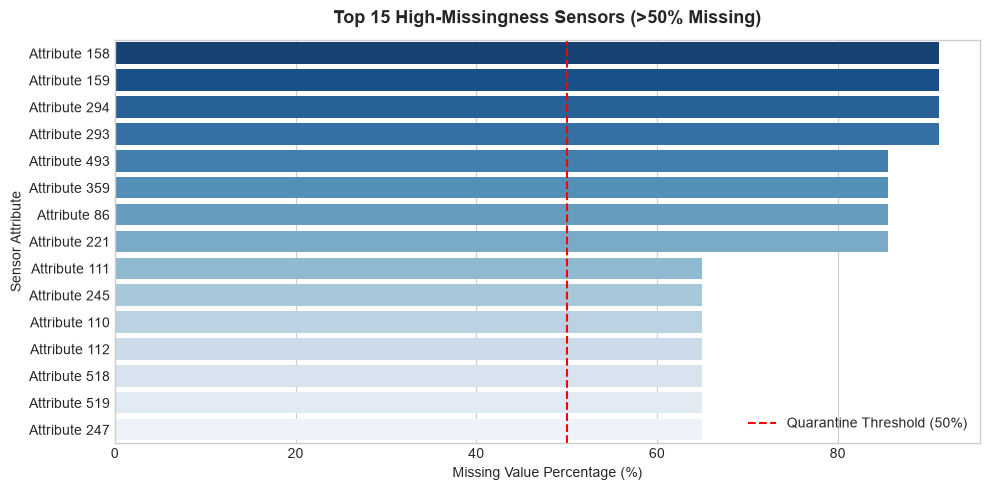

Total Sensors Quarantined due to >50% Missingness: 28


In [3]:
high_missing = pd.read_csv(QUALITY_DIR / "high_missing_columns.csv")

plt.figure(figsize=(10, 5))
sns.barplot(data=high_missing.head(15), x="missing_pct", y="column", palette="Blues_r")
plt.title("Top 15 High-Missingness Sensors (>50% Missing)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Missing Value Percentage (%)")
plt.ylabel("Sensor Attribute")
plt.axvline(50, color='red', linestyle='--', label='Quarantine Threshold (50%)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Total Sensors Quarantined due to >50% Missingness: {len(high_missing)}")


---
## 7. Production Quality & Class Imbalance

Semiconductor manufacturing inherently exhibits severe class imbalance: high-yield processes produce relatively few defective units.


C:\Users\ZhuanZ1\AppData\Local\Temp\ipykernel_17968\4130255907.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Pass (-1)', 'Fail (+1)'], y=[pass_count, fail_count], palette=colors, ax=ax[1])


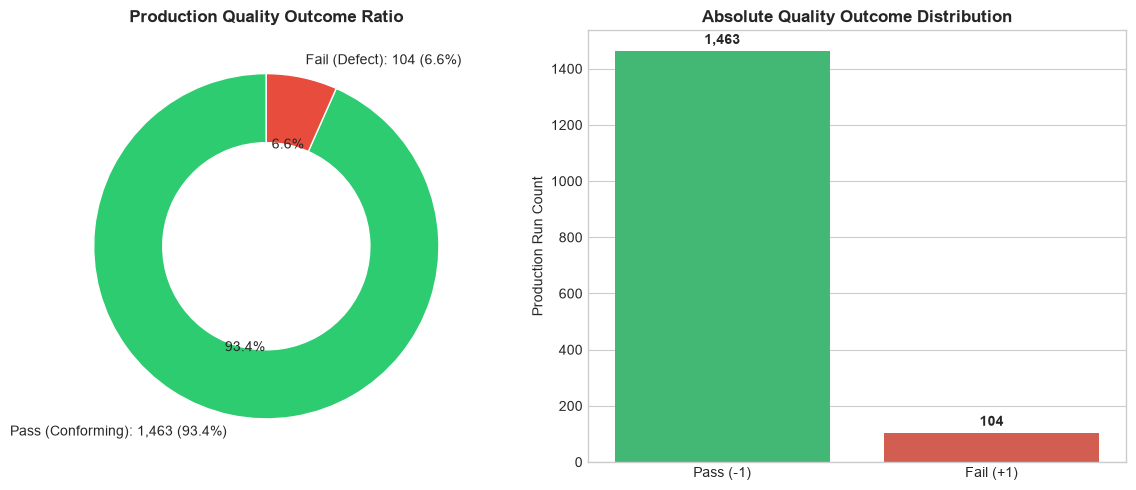

Baseline Defect Rate: 6.64%


In [4]:
target = labels.iloc[:, 0]
counts = target.value_counts()
pass_count = counts.get(-1, 0)
fail_count = counts.get(1, 0)
total_runs = len(target)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Donut chart
colors = ['#2ecc71', '#e74c3c']
labels_list = [
    f"Pass (Conforming): {pass_count:,} ({pass_count/total_runs:.1%})",
    f"Fail (Defect): {fail_count:,} ({fail_count/total_runs:.1%})"
]
ax[0].pie(
    [pass_count, fail_count],
    labels=labels_list,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor='white')
)
ax[0].set_title("Production Quality Outcome Ratio", fontsize=12, fontweight='bold')

# Bar chart with log scale
sns.barplot(x=['Pass (-1)', 'Fail (+1)'], y=[pass_count, fail_count], palette=colors, ax=ax[1])
ax[1].set_ylabel("Production Run Count")
ax[1].set_title("Absolute Quality Outcome Distribution", fontsize=12, fontweight='bold')
for i, v in enumerate([pass_count, fail_count]):
    ax[1].text(i, v + 25, f"{v:,}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Baseline Defect Rate: {fail_count / total_runs:.2%}")


### Cost of Quality (CoQ) Financial Formulation
In this environment, an unweighted accuracy score is deceptive:
$$\text{Accuracy of Dummy Majority Classifier} = \frac{1463}{1567} = 93.36\%$$

An operational model must be calibrated against business economics:
* **Cost of False Negative ($C_{FN}$):** An undetected defect enters subsequent assembly, packaging, or customer delivery. Estimated cost = **£450 per unit**.
* **Cost of False Positive ($C_{FP}$):** A conforming unit is flagged for secondary inspection or automated re-test. Estimated cost = **£25 per unit**.

$$\text{Expected Cost} = (FN \times £450) + (FP \times £25)$$


---
## 8. Initial Findings

1. **Zero Duplicate Rows:** The ingestion layer verified exact entity uniqueness across all 1,567 lots.
2. **116 Constant Columns:** 116 sensor attributes have zero variance across all observations (`nunique <= 1`). These carry zero predictive power and can be dropped immediately to reduce matrix dimensionality from 590 to 474.
3. **28 High-Missingness Features:** 28 sensors have over 50% missing data (with the worst at 91.2% missingness). These will be quarantined in `core.dim_sensor`.
4. **Viable Candidate Features:** After removing constant (116) and high-missingness (28) features, **446 continuous sensor features** remain active for predictive modeling.
5. **Temporal Span:** The data reflects 90 days of factory operations, demanding chronological validation rather than random K-Fold cross-validation.


---
## 9. Data Preparation Strategy

```text
[ 590 Raw Sensors ]
         │
         ├── Drop 116 Zero-Variance Features ──► (474 features remaining)
         │
         ├── Quarantine 28 Features (>50% NaNs) ──► (446 Candidate Features)
         │
         ├── Chronological Train/Test Split (70/30 or 80/20)
         │
         ├── Median / KNN Imputation (Fitted on Train Set Only)
         │
         └── Robust Standardisation (Interquartile Scaling for Outlier Resilience)
```


---
## 10. Next Steps

* **Step 3:** Deploy PostgreSQL schema (`staging`, `core`, `analytics`) and run the dimensional ETL pipeline.
* **Step 4:** Execute SQL operational analytics (daily yield trends, shift variance, scrap cost quantification).
* **Step 5:** Train baseline Logistic Regression and tree ensembles (Random Forest, XGBoost) with cost-sensitive threshold optimization.
* **Step 6:** Compute SHAP values to attribute specific chamber/sensor anomalies to predicted defects for plant engineers.
